# 14 — A Two-Layer Neural Network

We now have the pieces for

$$
X \rightarrow \text{affine} \rightarrow \text{ReLU}
\rightarrow \text{affine} \rightarrow \text{Softmax loss}.
$$

This notebook has four core exercises. Softmax is provided as a recap because it was derived and checked [earlier](./08_softmax_gradient_checking.ipynb).

## Learning objectives

- track all parameter, activation, and gradient shapes;
- implement inference and training modes;
- combine Softmax data loss with L2 regularization;
- backpropagate through the complete network;
- numerically check every parameter;
- train with minibatch SGD on nonlinear toy data.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from cs231n_practice.gradient_check import (
    eval_numerical_gradient,
    relative_error,
)
from cs231n_practice.layers import (
    affine_backward,
    affine_forward,
    affine_relu_backward,
    affine_relu_forward,
)

np.set_printoptions(precision=6, suppress=True)
SEED = 42


## 1. Architecture and shapes

For input dimension $D$, hidden dimension $H$, and $C$ classes:

```text
X:      (N, D)
W1:     (D, H)    b1: (H,)
hidden: (N, H)
W2:     (H, C)    b2: (C,)
scores: (N, C)
```

It is called a **two-layer network** because it has two learned weight transformations, even though it has only one hidden layer.


In [2]:
def initialize_two_layer_parameters(
    input_dim: int,
    hidden_dim: int,
    num_classes: int,
    *,
    weight_scale: float,
    seed: int,
) -> dict[str, np.ndarray]:
    """Create small random weights and zero biases."""
    generator = np.random.default_rng(seed)
    return {
        "W1": generator.normal(
            scale=weight_scale, size=(input_dim, hidden_dim)
        ),
        "b1": np.zeros(hidden_dim),
        "W2": generator.normal(
            scale=weight_scale, size=(hidden_dim, num_classes)
        ),
        "b2": np.zeros(num_classes),
    }


### Exercise 1 — Implement the forward pass

Use the reusable layers. Return scores and both caches in forward order.


In [3]:
def two_layer_forward(
    X: np.ndarray,
    parameters: dict[str, np.ndarray],
) -> tuple[np.ndarray, tuple]:
    """Return class scores and caches for a two-layer network."""
    # Compute affine-ReLU with W1 and b1.
    hidden, hidden_cache = affine_relu_forward(X, parameters["W1"], parameters["b1"])
    # Compute output affine with W2 and b2.
    scores, output_cache = affine_forward(hidden, parameters["W2"], parameters["b2"])
    return scores, (hidden_cache, output_cache)


X_small = np.array([
    [1.0, -2.0],
    [0.5, 1.5],
    [-1.0, 0.25],
    [2.0, 0.5],
])
parameters_small = {
    "W1": np.array([
        [0.1, -0.2, 0.3, 0.4],
        [-0.5, 0.6, 0.7, -0.8],
    ]),
    "b1": np.array([0.2, -0.1, 0.4, 0.05]),
    "W2": np.array([
        [0.2, -0.4, 0.1],
        [-0.3, 0.5, 0.2],
        [0.6, -0.1, -0.2],
        [0.4, 0.3, -0.5],
    ]),
    "b2": np.array([0.1, -0.2, 0.05]),
}

scores_small, forward_cache = two_layer_forward(
    X_small, parameters_small
)
assert scores_small.shape == (4, 3)
assert len(forward_cache) == 2
print(scores_small)


[[ 1.18   -0.105  -0.845 ]
 [ 0.85   -0.01   -0.13  ]
 [ 0.19   -0.1025  0.045 ]
 [ 1.12   -0.26   -0.43  ]]


## 2. Softmax and complete backward pass

The supplied Softmax function returns mean cross-entropy and

$$
dS=\frac{P-Y}{N}.
$$

more about it in previous [softmax gradient notebook](./08_softmax_gradient_checking.ipynb)


In [4]:
def softmax_loss(
    scores: np.ndarray,
    labels: np.ndarray,
) -> tuple[float, np.ndarray]:
    """Return stable mean cross-entropy and its score gradient."""
    shifted = scores - scores.max(axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    sum_exp_scores = exp_scores.sum(axis=1, keepdims=True)
    probabilities = exp_scores / sum_exp_scores
    correct_shifted = shifted[np.arange(scores.shape[0]), labels]
    loss = np.mean(np.log(sum_exp_scores[:, 0]) - correct_shifted)
    dscores = probabilities.copy()
    dscores[np.arange(scores.shape[0]), labels] -= 1.0
    dscores /= scores.shape[0]
    return float(loss), dscores


The total objective is

$$
L=L_{data}+\lambda\left(\sum W_1^2+\sum W_2^2\right).
$$

Thus the regularization gradients are $2\lambda W_1$ and $2\lambda W_2$. Biases are not regularized.

Backpropagation reverses the graph:

```text
Softmax -> output affine backward -> hidden affine-ReLU backward
```


### Exercise 2 — Implement loss and backpropagation

If `labels is None`, return scores. Otherwise return total loss and gradients for all four parameters.


In [10]:
def two_layer_loss(
    parameters: dict[str, np.ndarray],
    X: np.ndarray,
    labels: np.ndarray | None = None,
    *,
    regularization_strength: float = 0.0,
):
    """Return scores, or loss and gradients when labels are provided."""
    scores, (hidden_cache, output_cache) = two_layer_forward(
        X, parameters
    )
    if labels is None:
        return scores

    # Compute Softmax loss and add both weight penalties.
    data_loss, dscores = softmax_loss(scores, labels)
    regularization_loss = regularization_strength * (
        np.sum(parameters["W1"] ** 2)
        + np.sum(parameters["W2"] ** 2)
    )
    loss = data_loss + regularization_loss

    # Backpropagate through output affine, then affine-ReLU.
    dhidden, dW2, db2 = affine_backward(
        dscores,
        output_cache,
    )
    _, dW1, db1 = affine_relu_backward(
        dhidden,
        hidden_cache,
    )
     

    # Add regularization to dW1 and dW2.
    dW1 += 2 * regularization_strength * parameters["W1"]
    dW2 += 2 * regularization_strength * parameters["W2"]

    gradients = {
        "W1": dW1,
        "b1": db1,
        "W2": dW2,
        "b2": db2,
    }
    return loss, gradients


labels_small = np.array([0, 1, 2, 1])
loss_small, gradients_small = two_layer_loss(
    parameters_small,
    X_small,
    labels_small,
    regularization_strength=0.1,
)
assert np.isfinite(loss_small)
assert set(gradients_small) == set(parameters_small)
for name in parameters_small:
    assert gradients_small[name].shape == parameters_small[name].shape
np.testing.assert_allclose(
    two_layer_loss(parameters_small, X_small), scores_small
)
print("loss:", loss_small)


loss: 1.517878255678432


## 3. Check all four parameters

Each numerical check replaces only one parameter while holding the other three fixed. The examples keep ReLU pre-activations away from zero.


### Exercise 3 — Complete the gradient-check loop

Create a trial dictionary containing the candidate parameter and return its scalar loss. Use absolute tolerance because correct gradients can contain zeros.


In [11]:
regularization_strength = 0.1
_, analytical_gradients = two_layer_loss(
    parameters_small,
    X_small,
    labels_small,
    regularization_strength=regularization_strength,
)
check_results = {}

for name, parameter in parameters_small.items():
    def loss_with_candidate(candidate: np.ndarray) -> float:
        # Copy parameters and replace only the current entry.
        parameters_copy = parameters_small.copy()
        parameters_copy[name] = candidate
        return two_layer_loss(
            parameters_copy,
            X_small,
            labels_small,
            regularization_strength=regularization_strength,
        )[0]

    numerical_gradient = eval_numerical_gradient(loss_with_candidate, parameter)
    analytical_gradient = analytical_gradients[name]
    check_results[name] = {
        "relative_error": relative_error(
            analytical_gradient, numerical_gradient
        ),
        "max_absolute_error": float(
            np.max(np.abs(analytical_gradient - numerical_gradient))
        ),
    }
    np.testing.assert_allclose(
        analytical_gradient,
        numerical_gradient,
        rtol=1e-7,
        atol=1e-8,
    )

for name, result in check_results.items():
    print(name, result)


W1 {'relative_error': 2.3237547475714797e-10, 'max_absolute_error': 1.4019650024232888e-11}
b1 {'relative_error': 1.7662245288053418e-10, 'max_absolute_error': 1.3392759123931341e-11}
W2 {'relative_error': 4.578001937094881e-10, 'max_absolute_error': 8.68715863133751e-12}
b2 {'relative_error': 2.3204736505394725e-11, 'max_absolute_error': 6.553479980908605e-12}


## 4. Train on nonlinear spiral data

A hidden ReLU layer can form nonlinear piecewise-linear boundaries. We use all toy examples to demonstrate optimization; training accuracy is not an estimate of generalization.


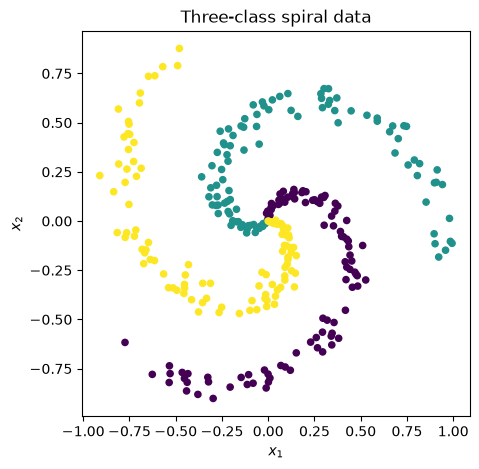

In [12]:
def make_spiral_data(
    points_per_class: int = 100,
    num_classes: int = 3,
    noise: float = 0.2,
    *,
    seed: int = SEED,
) -> tuple[np.ndarray, np.ndarray]:
    """Create a reproducible two-dimensional spiral dataset."""
    generator = np.random.default_rng(seed)
    X = np.zeros((points_per_class * num_classes, 2))
    labels = np.zeros(points_per_class * num_classes, dtype=np.int64)

    for class_index in range(num_classes):
        indices = slice(
            class_index * points_per_class,
            (class_index + 1) * points_per_class,
        )
        radius = np.linspace(0.0, 1.0, points_per_class)
        angle = np.linspace(
            class_index * 4.0,
            (class_index + 1) * 4.0,
            points_per_class,
        )
        angle += generator.normal(scale=noise, size=points_per_class)
        X[indices] = np.column_stack(
            [radius * np.sin(angle), radius * np.cos(angle)]
        )
        labels[indices] = class_index

    return X, labels


X_spiral, y_spiral = make_spiral_data()
plt.figure(figsize=(5, 5))
plt.scatter(
    X_spiral[:, 0], X_spiral[:, 1],
    c=y_spiral, cmap="viridis", s=20,
)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Three-class spiral data")
plt.show()


### Exercise 4 — Implement minibatch SGD

Each iteration samples a minibatch, computes loss and gradients, updates all parameters, and records loss. Copy initial parameters so the caller is not mutated.


In [32]:
from cs231n_practice.training import (
    sample_minibatch,
)

Initial mean loss: 0.8093787247297345
Final mean loss: 0.34817955505026943
Training accuracy: 0.9633333333333334


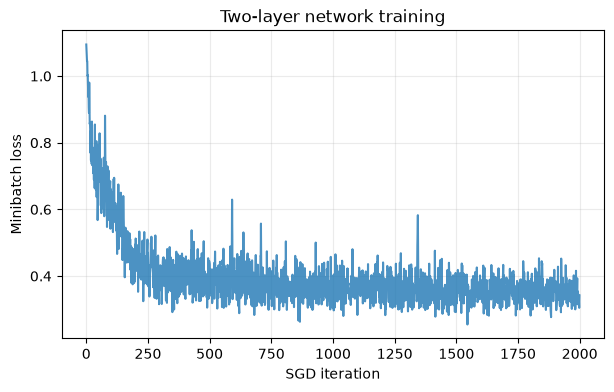

In [33]:
def train_two_layer_network(
    initial_parameters: dict[str, np.ndarray],
    X: np.ndarray,
    labels: np.ndarray,
    *,
    learning_rate: float,
    regularization_strength: float,
    batch_size: int,
    num_iterations: int,
    seed: int,
) -> tuple[dict[str, np.ndarray], np.ndarray]:
    """Train a two-layer network with vanilla minibatch SGD."""
    parameters = {
        name: value.copy()
        for name, value in initial_parameters.items()
    }
    losses = np.empty(num_iterations)
    generator = np.random.default_rng(seed)

    for iteration in range(num_iterations):
        # Sample indices without replacement and form a minibatch.
        minibatch_X, minibatch_y = sample_minibatch(X, labels, batch_size, generator)

        # Compute minibatch loss and gradients.
        loss, gradients = two_layer_loss(
            parameters,
            minibatch_X,
            minibatch_y,
            regularization_strength=regularization_strength,
        )

        # Update every parameter.
        for parameter_name in parameters.keys():
            parameters[parameter_name] -= learning_rate * gradients[parameter_name]

        losses[iteration] = loss

    return parameters, losses


def predict_two_layer(
    parameters: dict[str, np.ndarray],
    X: np.ndarray,
) -> np.ndarray:
    """Return the highest-scoring class for every example."""
    logits = two_layer_forward(X, parameters)[0]
    return np.argmax(logits, axis=1)


initial_parameters = initialize_two_layer_parameters(
    input_dim=2,
    hidden_dim=50,
    num_classes=3,
    weight_scale=0.1,
    seed=SEED + 1,
)
initial_before = {
    name: value.copy()
    for name, value in initial_parameters.items()
}
trained_parameters, loss_history = train_two_layer_network(
    initial_parameters,
    X_spiral,
    y_spiral,
    learning_rate=1.0,
    regularization_strength=1e-3,
    batch_size=64,
    num_iterations=2_000,
    seed=SEED + 2,
)
for name in initial_parameters:
    np.testing.assert_array_equal(
        initial_parameters[name], initial_before[name]
    )

training_predictions = predict_two_layer(
    trained_parameters, X_spiral
)
training_accuracy = np.mean(training_predictions == y_spiral)
print("Initial mean loss:", loss_history[:50].mean())
print("Final mean loss:", loss_history[-50:].mean())
print("Training accuracy:", training_accuracy)

assert loss_history[-50:].mean() < loss_history[:50].mean()
assert training_accuracy > 0.85

plt.figure(figsize=(7, 4))
plt.plot(loss_history, alpha=0.8)
plt.xlabel("SGD iteration")
plt.ylabel("Minibatch loss")
plt.title("Two-layer network training")
plt.grid(alpha=0.25)
plt.show()


## 5. Decision boundary


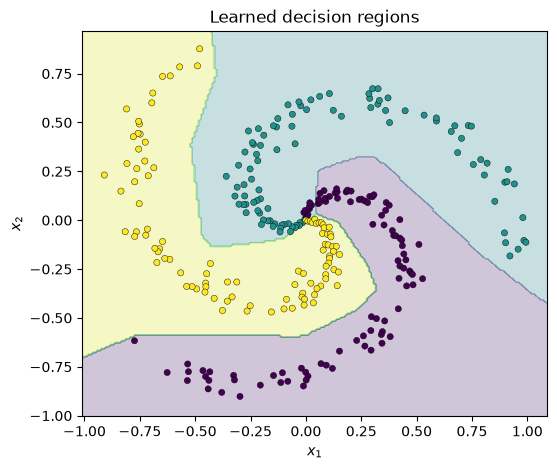

In [31]:
grid_step = 0.01
x1_limits = (
    X_spiral[:, 0].min() - 0.1,
    X_spiral[:, 0].max() + 0.1,
)
x2_limits = (
    X_spiral[:, 1].min() - 0.1,
    X_spiral[:, 1].max() + 0.1,
)
grid_x1, grid_x2 = np.meshgrid(
    np.arange(*x1_limits, grid_step),
    np.arange(*x2_limits, grid_step),
)
grid_points = np.column_stack([
    grid_x1.ravel(), grid_x2.ravel()
])
grid_predictions = predict_two_layer(
    trained_parameters, grid_points
).reshape(grid_x1.shape)

plt.figure(figsize=(6, 5))
plt.contourf(
    grid_x1, grid_x2, grid_predictions,
    alpha=0.25, cmap="viridis",
)
plt.scatter(
    X_spiral[:, 0], X_spiral[:, 1],
    c=y_spiral, cmap="viridis",
    edgecolors="black", linewidths=0.3, s=20,
)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Learned decision regions")
plt.show()


## Reflection

Add a Markdown cell answering:

1. Why is this called a two-layer network with only one hidden layer?
2. What are the shapes of all four parameters?
3. What makes it more expressive than a linear classifier?
4. Why does inference return scores without loss or gradients?
5. In what order are operations visited during backpropagation?
6. Why does regularization affect weights but not biases here?
7. Why check all parameters numerically before training?
8. Why copy initial parameters inside the training function?
9. Why can minibatch loss fluctuate during successful training?
10. What does high spiral training accuracy demonstrate, and what does it not demonstrate?
11. What remains before applying this model to CIFAR-10?

Next we will extract Softmax and the two-layer model into reusable code, then train and tune it on CIFAR-10.


1. It is called a two-layer network because it has two learnable affine transformations: one using W1, b1 and another using W2, b2. The input itself is not counted as a layer.
2. With input dimension $D$, hidden dimension $H$, and $C$ classes: W1: $(D,H)$ b1: $(H,)$ W2: $(H,C)$ b2: $(C,)$
3. ReLU introduces nonlinearity between the affine transformations. This prevents them from collapsing into one affine operation and allows piecewise-linear nonlinear decision boundaries.
4. During inference, labels are unavailable and we only need class scores to select predictions. Loss and gradients are needed for evaluating and updating parameters during training.
5. During inference, labels are unavailable and we only need class scores to select predictions. Loss and gradients are needed for evaluating and updating parameters during training. Softmax loss
 -> output affine backward -> ReLU backward -> first affine backward
6. Our objective regularizes weights because they control feature connections and model complexity. Biases are excluded by design. It is possible to regularize biases, but it is uncommon and not our chosen convention.
7. Numerical checks verify that the analytical gradients for all four parameters correctly represent derivatives of the implemented loss before those gradients are trusted during training.
8. Copying prevents the training function from modifying the caller’s initial arrays. This permits fair repeated experiments from the same initialization. Reproducibility also requires using the same random seed.
9. Every random minibatch contains different examples and therefore produces a different estimate of the full training loss and gradient. Individual losses can fluctuate even while their overall trend decreases.
10. High training accuracy demonstrates that the network has enough capacity and that optimization successfully fits the spiral training data. It does not demonstrate generalization to unseen spiral examples or performance on CIFAR-10.
11. Before CIFAR-10, we need a reusable tested model, image preprocessing, train/validation/test handling, suitable input dimensions, and hyperparameter tuning for hidden size, initialization scale, learning rate, regularization, batch size, and training duration.